# 02 — From Fourier series to spherical harmonics

Spherical harmonics are usually introduced by dropping $Y_\ell^m(\theta,\phi)$ on
the reader with a factorial-laden normalisation constant and a Legendre
polynomial. That is the *definition*, not the *idea*.

The idea is much simpler, and you already know it if you know Fourier series. This
notebook rebuilds Fourier on a circle from scratch — including the complex-number
machinery — and then makes the jump to the sphere precise.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

import shlib as sh
import shplot as sp

sp.use_style()
np.set_printoptions(precision=4, suppress=True, linewidth=110)

## 1. The pattern: signals as sums of basis functions

Take any periodic function on a circle, $f(\theta)$ with $f(\theta + 2\pi) = f(\theta)$.
Fourier's claim is that it can be written as a sum of sines and cosines:

$$f(\theta) = a_0 + \sum_{n=1}^{\infty}\Big(a_n\cos n\theta + b_n\sin n\theta\Big)$$

Higher $n$ means faster wiggling — higher **frequency**. If $f$ is smooth, the
coefficients die off quickly and you can truncate the sum with little loss. If $f$
has a sharp edge, they die off slowly.

That is *exactly* the deal we want for lighting. So the question becomes: what
plays the role of $\cos n\theta$ on a sphere?

Before we can answer that, we need to understand *why* this works at all. The
answer is orthogonality, and the cleanest way to see it uses complex numbers.

## 2. Complex exponentials, and why they're worth the trouble

Euler's formula packs a cosine and a sine into one object:

$$e^{i\theta} = \cos\theta + i\sin\theta$$

Read geometrically: $e^{i\theta}$ is **the point on the unit circle at angle
$\theta$**. That is all a complex number of unit modulus is — a rotation.

Three properties make this the right tool:

| property | statement | why we care |
|---|---|---|
| rotation is multiplication | $e^{i\alpha}e^{i\beta} = e^{i(\alpha+\beta)}$ | composing rotations becomes arithmetic |
| one symbol, two waves | $\cos n\theta = \mathrm{Re}\,e^{in\theta}$, $\sin n\theta = \mathrm{Im}\,e^{in\theta}$ | one basis family instead of two |
| differentiation is scaling | $\frac{d}{d\theta}e^{in\theta} = in\,e^{in\theta}$ | these are eigenfunctions of the derivative |

That last one is the deep reason. $e^{in\theta}$ are the **eigenfunctions of the
Laplacian on the circle** — the functions that the differential operator merely
scales rather than reshapes. Spherical harmonics will turn out to be exactly the
same thing on the sphere, and that is not a coincidence; it is the definition.

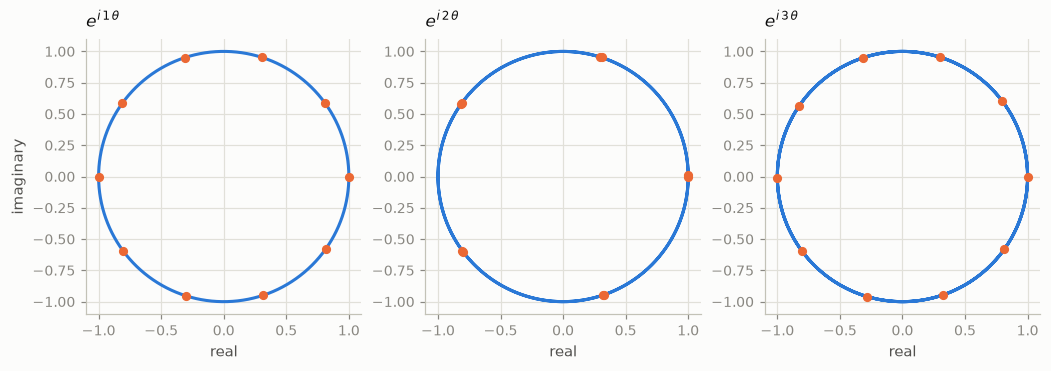

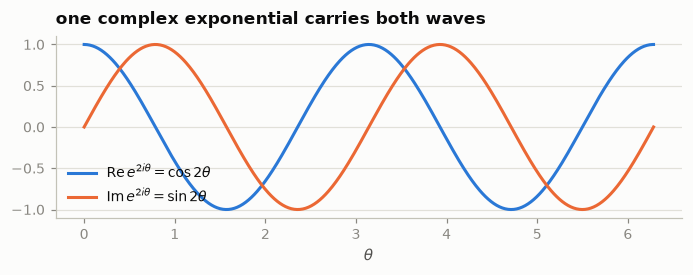

In [2]:
# e^{i n theta} traced on the complex plane: n full turns as theta goes 0..2pi.
th = np.linspace(0, 2*np.pi, 600)
fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.2))
for ax, n in zip(axes, [1, 2, 3]):
    z = np.exp(1j * n * th)
    ax.plot(z.real, z.imag, color=sp.SERIES[0], lw=2)
    ax.plot(z.real[::60], z.imag[::60], "o", color=sp.SERIES[1], ms=5)
    ax.set_aspect("equal"); ax.set_title(f"$e^{{i\\,{n}\\,\\theta}}$")
    ax.set_xlabel("real"); ax.set_ylabel("imaginary" if n == 1 else "")
    ax.grid(True, axis="both")
fig.tight_layout()

# Real and imaginary parts are just cos and sin.
fig, ax = plt.subplots(figsize=(6.4, 2.6))
ax.plot(th, np.exp(2j*th).real, color=sp.SERIES[0], label="$\\mathrm{Re}\\,e^{2i\\theta} = \\cos 2\\theta$")
ax.plot(th, np.exp(2j*th).imag, color=sp.SERIES[1], label="$\\mathrm{Im}\\,e^{2i\\theta} = \\sin 2\\theta$")
ax.set_xlabel("$\\theta$"); ax.legend(); ax.set_title("one complex exponential carries both waves")
fig.tight_layout()

## 3. Orthogonality: the property that makes it all work

Define an **inner product** on functions over the circle:

$$\langle f, g\rangle \;=\; \int_0^{2\pi} f(\theta)\,\overline{g(\theta)}\;d\theta$$

(The bar is complex conjugation. For real functions it does nothing; for complex
ones it is what makes $\langle f,f\rangle$ come out real and positive.)

This behaves exactly like the dot product on vectors — it measures "how much of
$g$ is in $f$". And the complex exponentials are **orthogonal** under it:

$$\langle e^{in\theta}, e^{im\theta}\rangle = \int_0^{2\pi} e^{in\theta}e^{-im\theta}\,d\theta
= \int_0^{2\pi} e^{i(n-m)\theta}\,d\theta = \begin{cases}2\pi & n = m\\ 0 & n \neq m\end{cases}$$

The $n \neq m$ case vanishes because a complete number of turns around the circle
sums to zero — the positive and negative parts cancel exactly.

**Why this matters:** an orthogonal basis means each coefficient can be found
*independently*, by a single projection, with no solving of simultaneous equations:

$$c_n = \frac{1}{2\pi}\langle f, e^{in\theta}\rangle$$

That is the entire computational reason spherical harmonics are practical. Baking a
light probe is just this integral, once per coefficient.

Gram matrix (should be identity):  max |G - I| = 2.22e-16


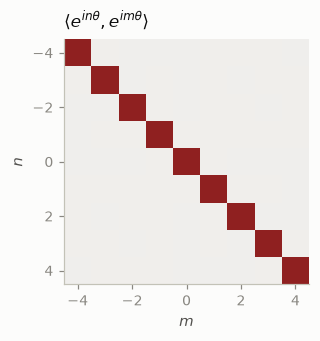

In [3]:
# Verify orthogonality numerically -- the Gram matrix should be the identity.
N = 4000
th = (np.arange(N) + 0.5) / N * 2*np.pi
ns = np.arange(-4, 5)
B = np.exp(1j * np.outer(th, ns))                 # (N, 9) basis samples
G = (B.conj().T @ B) * (2*np.pi/N) / (2*np.pi)    # normalised Gram matrix

print("Gram matrix (should be identity):  max |G - I| =",
      f"{np.abs(G - np.eye(len(ns))).max():.2e}")

fig, ax = plt.subplots(figsize=(3.6, 3.2))
ax.imshow(G.real, cmap=sp.CM_DIVERGING, vmin=-1, vmax=1,
          extent=[-4.5, 4.5, 4.5, -4.5])
ax.set_title("$\\langle e^{in\\theta}, e^{im\\theta}\\rangle$")
ax.set_xlabel("$m$"); ax.set_ylabel("$n$"); ax.grid(False)
fig.tight_layout()

## 4. Projection, truncation, and ringing — the whole story in 1D

Now the round trip. Project a function onto the basis, keep only the first $N$
coefficients, and reconstruct. Every phenomenon we will meet on the sphere shows up
here first, where it is easy to see.

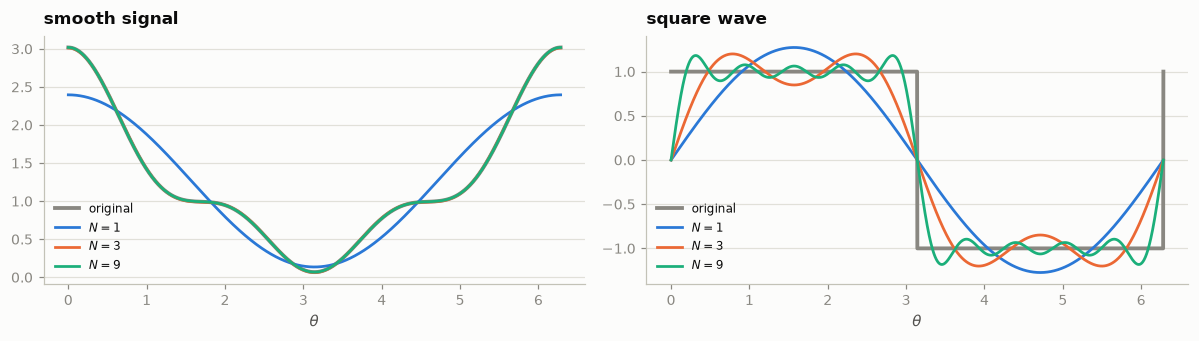

In [4]:
def fourier_project(f, nmax, N=8000):
    th = (np.arange(N) + 0.5) / N * 2*np.pi
    ns = np.arange(-nmax, nmax+1)
    B = np.exp(1j * np.outer(th, ns))
    return ns, (B.conj().T @ f(th)) * (2*np.pi/N) / (2*np.pi)

def fourier_recon(ns, c, th):
    return (np.exp(1j * np.outer(th, ns)) @ c).real

# Two test signals: one smooth, one with a hard edge.
smooth = lambda t: np.exp(np.cos(t)) + 0.3*np.cos(3*t)
square = lambda t: np.where((t % (2*np.pi)) < np.pi, 1.0, -1.0)

th = np.linspace(0, 2*np.pi, 2000)
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.2))
for ax, (fn, name) in zip(axes, [(smooth, "smooth signal"), (square, "square wave")]):
    ax.plot(th, fn(th), color=sp.MUTED, lw=2.5, label="original")
    for k, nmax in enumerate([1, 3, 9]):
        ns, c = fourier_project(fn, nmax)
        ax.plot(th, fourier_recon(ns, c, th), color=sp.SERIES[k], lw=1.8,
                label=f"$N={nmax}$")
    ax.set_title(name); ax.set_xlabel("$\\theta$"); ax.legend(fontsize=8)
fig.tight_layout()

Two lessons, both of which transfer verbatim to the sphere:

**The smooth signal converges fast.** By $N=3$ it is already close; by $N=9$ it is
visually exact.

**The square wave rings.** Those overshoots at the discontinuities are the **Gibbs
phenomenon**, and they do not go away as you add terms — they get narrower but stay
about 9% tall, forever. On a sphere this becomes the dark halo around a bright
light, and *negative radiance*, which is physically nonsense. Notebook 05 deals
with it.

Look at the coefficient magnitudes to see why:

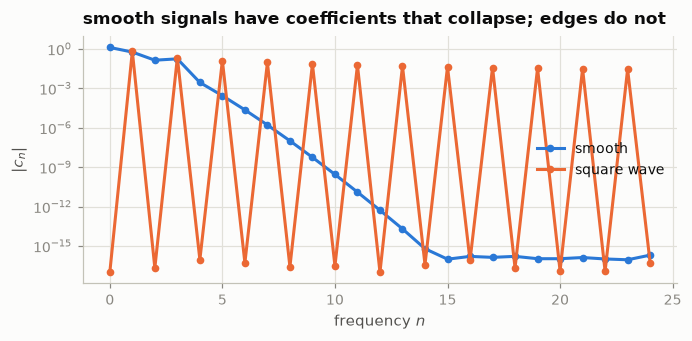

In [5]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
for k, (fn, name) in enumerate([(smooth, "smooth"), (square, "square wave")]):
    ns, c = fourier_project(fn, 24)
    pos = ns >= 0
    ax.semilogy(ns[pos], np.maximum(np.abs(c[pos]), 1e-17), "o-",
                color=sp.SERIES[k], label=name, ms=4)
ax.set_xlabel("frequency $n$"); ax.set_ylabel("$|c_n|$")
ax.set_title("smooth signals have coefficients that collapse; edges do not")
ax.legend(); ax.grid(True, which="both", axis="both")
fig.tight_layout()

The smooth signal's coefficients fall off the bottom of the plot within a few
terms. The square wave's decay as $1/n$ — you would need thousands of terms.

**Truncating a series is a low-pass filter.** That is the one sentence to carry
into the rest of this series.

## 5. Parseval: coefficients carry the energy

One more fact we will use to measure error:

$$\int_0^{2\pi} |f(\theta)|^2 d\theta \;=\; 2\pi\sum_n |c_n|^2$$

The total "energy" of a signal equals the sum of the squared coefficients. So the
error from truncating at $N$ is exactly the energy in the discarded coefficients —
we can quantify how good an approximation is *without ever reconstructing it*.

This is why notebook 06 can claim "9 coefficients capture 99% of irradiance" as a
precise, checkable statement rather than a vibe.

In [6]:
for fn, name in [(smooth, "smooth"), (square, "square wave")]:
    ns, c = fourier_project(fn, 40)
    energy = np.abs(c)**2
    total = energy.sum()
    print(f"\n{name}:")
    for nmax in (0, 1, 2, 4, 8, 16):
        kept = energy[np.abs(ns) <= nmax].sum()
        print(f"   keep |n| <= {nmax:<3}  ({2*nmax+1:>3} coeffs)   "
              f"{kept/total*100:6.2f}% of energy")


smooth:
   keep |n| <= 0    (  1 coeffs)    68.56% of energy
   keep |n| <= 1    (  3 coeffs)    95.89% of energy
   keep |n| <= 2    (  5 coeffs)    97.46% of energy
   keep |n| <= 4    (  9 coeffs)   100.00% of energy
   keep |n| <= 8    ( 17 coeffs)   100.00% of energy
   keep |n| <= 16   ( 33 coeffs)   100.00% of energy

square wave:
   keep |n| <= 0    (  1 coeffs)     0.00% of energy
   keep |n| <= 1    (  3 coeffs)    81.89% of energy
   keep |n| <= 2    (  5 coeffs)    81.89% of energy
   keep |n| <= 4    (  9 coeffs)    90.98% of energy
   keep |n| <= 8    ( 17 coeffs)    95.93% of energy
   keep |n| <= 16   ( 33 coeffs)    98.47% of energy


## 6. The jump to the sphere

Here is the analogy, stated carefully.

| | **circle** $S^1$ | **sphere** $S^2$ |
|---|---|---|
| coordinates | $\theta$ | $(\theta, \phi)$ |
| basis | $e^{in\theta}$ | $Y_\ell^m(\theta,\phi)$ |
| frequency index | $n \in \mathbb{Z}$ | band $\ell = 0,1,2,\dots$ |
| functions per frequency | 1 | $2\ell+1$ (orders $m = -\ell..\ell$) |
| inner product | $\int_0^{2\pi} f\bar g\,d\theta$ | $\int_{S^2} f\bar g\,d\omega$ |
| eigenfunctions of | $\frac{d^2}{d\theta^2}$ | the Laplacian $\nabla^2$ on the sphere |
| truncation | low-pass | low-pass |
| total coefficients to band $L$ | $2L+1$ | $(L+1)^2$ |

The one genuinely new feature is that **each frequency band has multiple
functions**. On a circle, "frequency 3" is one thing. On a sphere, band $\ell = 3$
is a 7-dimensional space, because there are many distinct ways to wiggle three
times on a sphere depending on orientation.

That degeneracy is not an inconvenience — it is the source of the single most
useful property spherical harmonics have:

> **Rotating a function mixes coefficients *within* a band, never across bands.**

A rotated band-2 function is still purely band-2. That is why you can rotate a
light probe into object space with three small matrix multiplies, why "band 1" is
meaningfully "the linear/directional part" no matter how you turn your head, and
why the cosine convolution in notebook 06 can be a simple per-band scale.

Why $(\ell+1)^2$ coefficients up to band $\ell$? Because $\sum_{k=0}^{\ell}(2k+1) = (\ell+1)^2$.
Hence the familiar numbers: **L1 → 4, L2 → 9, L4 → 25.**

In [7]:
print(f"{'band L':>7}{'coeffs (L+1)^2':>16}{'RGB floats':>13}{'bytes fp16':>12}")
print("-" * 50)
for L in range(6):
    n = (L+1)**2
    print(f"{L:>7}{n:>16}{n*3:>13}{n*3*2:>12}")

 band L  coeffs (L+1)^2   RGB floats  bytes fp16
--------------------------------------------------
      0               1            3           6
      1               4           12          24
      2               9           27          54
      3              16           48          96
      4              25           75         150
      5              36          108         216


## 7. What we have, and what's next

You now have the whole conceptual frame:

- A light probe stores a **function on a sphere**.
- We expand it in an **orthonormal basis** ordered by frequency.
- Each coefficient comes from **one independent projection integral**.
- **Truncating = low-passing**, which is cheap for smooth functions and rings for
  sharp ones.
- Bands are **rotation-closed**, which makes everything downstream tractable.

What we do *not* have yet is the actual basis. Notebook 03 derives $Y_\ell^m$ by
separation of variables and meets the associated Legendre polynomials.

---

**Next:** [03 — Legendre polynomials and the complex SH basis](03_legendre_and_complex_sh.ipynb)